In [1]:
import sys
!pip install pmdarima

In [2]:
import pandas as pd 
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set()
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Membaca Data

In [3]:
beras = pd.read_csv('Supply_Beras.csv',index_col='Periode', parse_dates=True, sep = ';')
print(beras.shape)
print(beras.head())

(48, 1)
            Produksi
Periode             
2017-01-01    808181
2017-02-01    803341
2017-03-01    802040
2017-04-01    788637
2017-05-01    775817


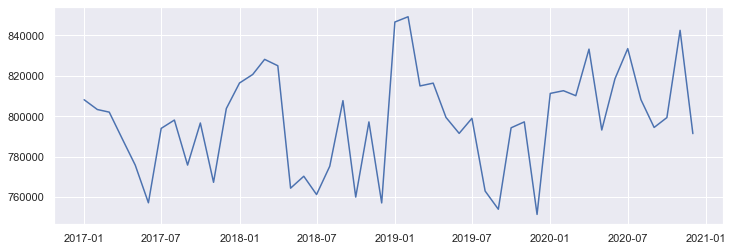

In [4]:
plt.figure(figsize=(12,4))
plt.plot(beras.index, beras['Produksi'])

# Memisah data

In [5]:
train = beras[:40]
test = beras[40:]

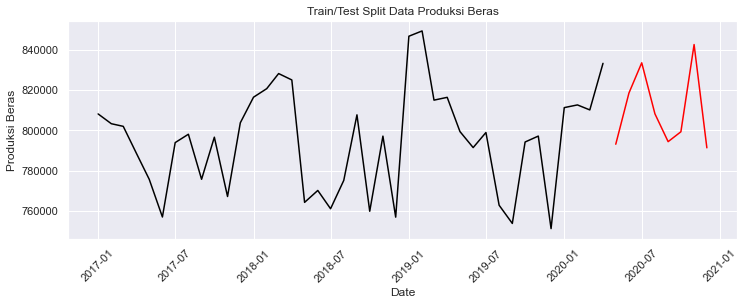

In [6]:
plt.figure(figsize=(12,4))
plt.plot(train, color = "black")
plt.plot(test, color = "red")
plt.ylabel('Produksi Beras')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test Split Data Produksi Beras")
plt.show()

# ARMA

Metode Autoregressive Moving Average (ARMA) memodelkan langkah berikutnya dalam urutan sebagai fungsi linier dari pengamatan dan kesalahan residual pada deret waktu sebelumnya. Metode ini menggabungkan kedua model Autoregression (AR) dan Moving Average (MA).

Implementasi Metode ARMA

Terlihat bahwa implementasi di bawah untuk memprediksi selama 15 waktu ke depan

In [8]:
y = train['Produksi']
ARMAmodel = SARIMAX(y, order = (1, 0, 1))
ARMAmodel = ARMAmodel.fit()
y_pred_ARMA = ARMAmodel.get_forecast(15)
y_pred_df_ARMA = y_pred_ARMA.conf_int(alpha = 0.05) 
y_pred_df_ARMA["Predictions"] = ARMAmodel.predict(start = y_pred_df_ARMA.index[0], end = y_pred_df_ARMA.index[-1])
y_pred_out_ARMA = y_pred_df_ARMA["Predictions"] 

Mencetak dan memvisualisasikan hasil prediksi metode ARMA

In [9]:
y_pred_out_ARMA

2020-05-01    819426.780327
2020-06-01    819302.225654
2020-07-01    819177.689914
2020-08-01    819053.173104
2020-09-01    818928.675220
2020-10-01    818804.196260
2020-11-01    818679.736222
2020-12-01    818555.295102
2021-01-01    818430.872897
2021-02-01    818306.469604
2021-03-01    818182.085221
2021-04-01    818057.719745
2021-05-01    817933.373172
2021-06-01    817809.045501
2021-07-01    817684.736727
Freq: MS, Name: Predictions, dtype: float64

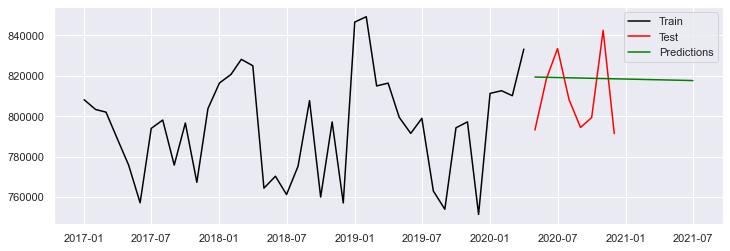

In [10]:
plt.figure(figsize=(12,4))
plt.plot(train, color = "black", label = "Train")
plt.plot(test, color = "red", label = "Test")
plt.plot(y_pred_out_ARMA, color='green', label = 'Predictions')
plt.legend()

In [11]:
arma_rmse = np.sqrt(mean_squared_error(y_pred_df_ARMA["Predictions"].values, y_pred_df_ARMA["Predictions"]))
print("RMSE: ",arma_rmse)

RMSE:  0.0


# ARIMA

Metode Autoregressive Integrated Moving Average (ARIMA) memodelkan deret waktu berikutnya dalam urutan sebagai fungsi linier dari pengamatan yang berbeda dan kesalahan residual pada deret waktu sebelumnya. Metode ini menggabungkan kedua model Autoregression (AR) dan Moving Average (MA) serta langkah pra-pemrosesan diferensial dari urutan untuk membuat urutan stasioner, yang disebut integrasi (I).


# Implementasi Metode ARIMA

In [12]:
ARIMAmodel = ARIMA(y, order = (1, 0, 1))
ARIMAmodel = ARIMAmodel.fit()

y_pred_ARIMA = ARIMAmodel.get_forecast(15)
y_pred_df_ARIMA = y_pred_ARIMA.conf_int(alpha = 0.05) 
y_pred_df_ARIMA["Predictions"] = ARIMAmodel.predict(start = y_pred_df_ARIMA.index[0], end = y_pred_df_ARIMA.index[-1])
y_pred_out_ARIMA = y_pred_df_ARIMA["Predictions"]

# Mencetak dan memvisualisasikan hasil prediksi metode ARIMA

In [13]:
y_pred_out_ARIMA

2020-05-01    806960.204568
2020-06-01    799728.509070
2020-07-01    796858.819686
2020-08-01    795720.066378
2020-09-01    795268.185035
2020-10-01    795088.868981
2020-11-01    795017.712587
2020-12-01    794989.476228
2021-01-01    794978.271445
2021-02-01    794973.825151
2021-03-01    794972.060768
2021-04-01    794971.360623
2021-05-01    794971.082791
2021-06-01    794970.972541
2021-07-01    794970.928792
Freq: MS, Name: Predictions, dtype: float64

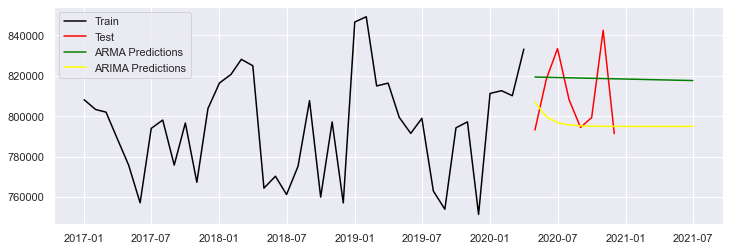

In [14]:
plt.figure(figsize=(12,4))
plt.plot(train, color = "black", label = "Train")
plt.plot(test, color = "red", label = "Test")
plt.plot(y_pred_out_ARMA, color='green', label = 'ARMA Predictions')
plt.plot(y_pred_out_ARIMA, color='Yellow', label = 'ARIMA Predictions')
plt.legend()

In [15]:
arima_rmse = np.sqrt(mean_squared_error(y_pred_df_ARMA["Predictions"].values, y_pred_df_ARIMA["Predictions"]))
print("RMSE: ",arima_rmse)

RMSE:  22434.303951536247


# SARIMA

Seasonal Autoregressive Integrated Moving Average (SARIMA) merupakan pengembangan dari model Autoregressive Integrated Moving Average (ARIMA) padadata runtun waktu yang memiliki pola musiman.

# Implementasi SARIMA

In [16]:
SARIMAXmodel = SARIMAX(y, order = (1, 0, 1), seasonal_order=(2,2,2,12))
SARIMAXmodel = SARIMAXmodel.fit()

y_pred_SARIMA = SARIMAXmodel.get_forecast(15)
y_pred_df_SARIMA = y_pred_SARIMA.conf_int(alpha = 0.05) 
y_pred_df_SARIMA["Predictions"] = SARIMAXmodel.predict(start = y_pred_df_SARIMA.index[0], end = y_pred_df_SARIMA.index[-1])
y_pred_out_SARIMA = y_pred_df_SARIMA["Predictions"] 

Mencetak dan memvisualisasikan hasil prediksi metode SARIMA

In [17]:
y_pred_out_SARIMA

2020-05-01    787959.050646
2020-06-01    780900.088108
2020-07-01    790475.313513
2020-08-01    745003.521916
2020-09-01    735959.086631
2020-10-01    789850.073640
2020-11-01    796550.738161
2020-12-01    736912.062587
2021-01-01    795644.122688
2021-02-01    798997.423416
2021-03-01    797920.530029
2021-04-01    829599.186509
2021-05-01    778642.611370
2021-06-01    771408.780946
2021-07-01    784903.702532
Freq: MS, Name: Predictions, dtype: float64

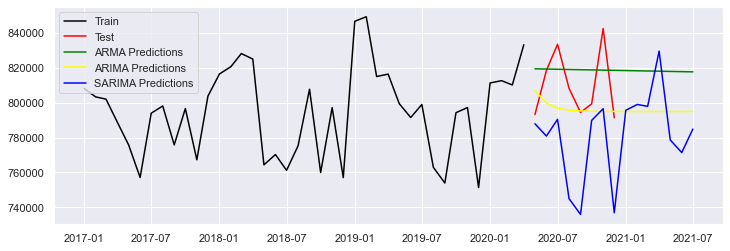

In [18]:
plt.figure(figsize=(12,4))
plt.plot(train, color = "black", label = "Train")
plt.plot(test, color = "red", label = "Test")
plt.plot(y_pred_out_ARMA, color='green', label = 'ARMA Predictions')
plt.plot(y_pred_out_ARIMA, color='Yellow', label = 'ARIMA Predictions')
plt.plot(y_pred_out_SARIMA, color='Blue', label = 'SARIMA Predictions')
plt.legend()

In [19]:
sarima_rmse = np.sqrt(mean_squared_error(y_pred_df_ARMA["Predictions"].values, y_pred_df_SARIMA["Predictions"]))
print("SARIMA RMSE: ",sarima_rmse)

SARIMA RMSE:  44614.55613699949


# Holt Winters

# Import Library

In [20]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error,mean_squared_error
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Membaca Data

In [21]:
beras = pd.read_csv('Supply_Beras.csv',index_col='Periode', parse_dates=True, sep = ';')
print(beras.shape)
print(beras.head())

(48, 1)
            Produksi
Periode             
2017-01-01    808181
2017-02-01    803341
2017-03-01    802040
2017-04-01    788637
2017-05-01    775817


<AxesSubplot:title={'center':'Produksi Beras'}, xlabel='Periode'>

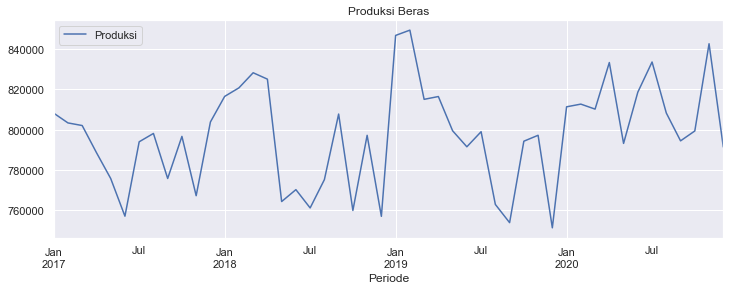

In [22]:
beras[['Produksi']].plot(title='Produksi Beras', figsize = (12,4))

Melihat pola trend dan trend musiman

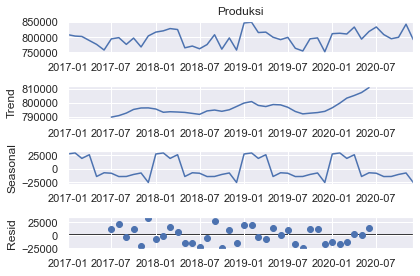

In [23]:
decompose_result = seasonal_decompose(beras['Produksi'],model='additive')
decompose_result.plot();

Mengatur frekuensi datatime

Tujuannya untuk menetapkan parameter index time series sebelum diolah lebih lanjut

In [24]:
beras.index.freq = 'MS'
m = 12
alpha = 1/(2*m)

# Single Exponential Smoothing

Single Exponential Smoothing merupakan metode peramalan yang digunakan untuk data stasioner atau data yang relatif stabil.

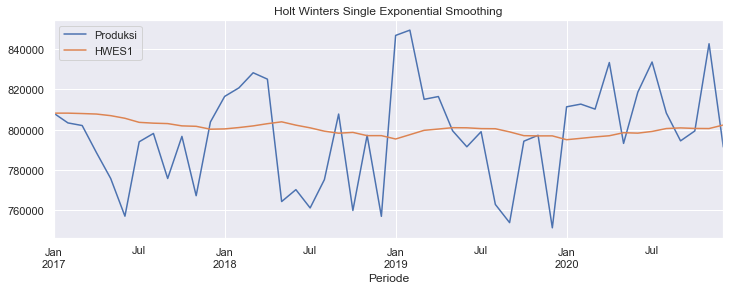

In [25]:
beras['HWES1'] = SimpleExpSmoothing(beras['Produksi']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues
beras[['Produksi','HWES1']].plot(title='Holt Winters Single Exponential Smoothing', figsize=(12,4));

# Double Exponential Smoothing

Double Exponential Smoothing digunakan untuk data yang memiliki tren atau data yang memiliki kecenderungan peningkatan atau penurunan dalam jangka panjang.

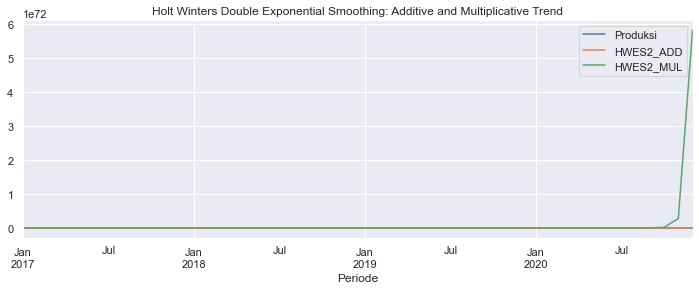

In [39]:
beras['HWES2_ADD'] = ExponentialSmoothing(beras['Produksi'],trend='add').fit().fittedvalues
beras['HWES2_MUL'] = ExponentialSmoothing(beras['Produksi'],trend='mul').fit().fittedvalues
beras[['Produksi','HWES2_ADD','HWES2_MUL']].plot(title='Holt Winters Double Exponential Smoothing: Additive and Multiplicative Trend', figsize = (12,4));

# Triple Exponential Smoothing

Double Exponential Smoothing digunakan untuk data yang memiliki tren atau data yang memiliki kecenderungan peningkatan atau penurunan dalam jangka panjang dan dipengaruhi oleh musim.

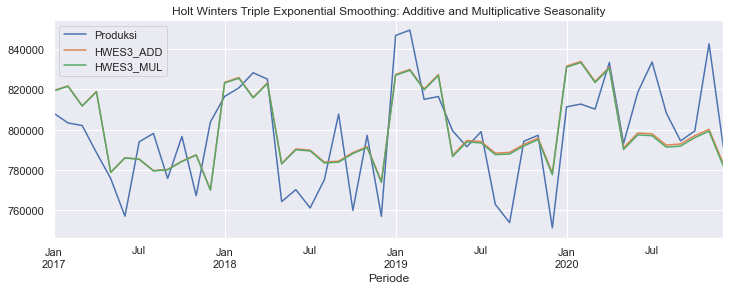

In [27]:
beras['HWES3_ADD'] = ExponentialSmoothing(beras['Produksi'],trend='add',seasonal='add',seasonal_periods=12).fit().fittedvalues
beras['HWES3_MUL'] = ExponentialSmoothing(beras['Produksi'],trend='mul',seasonal='mul',seasonal_periods=12).fit().fittedvalues
beras[['Produksi','HWES3_ADD','HWES3_MUL']].plot(title='Holt Winters Triple Exponential Smoothing: Additive and Multiplicative Seasonality', figsize = (12,4));

# Prediksi Data

In [28]:
f_prod= pd.read_csv('Supply_Beras.csv',index_col='Periode', parse_dates=True, sep = ';')

Mengatur frekuensi datatime

In [29]:
f_prod.index.freq='MS'

Mengetahui dimensi prediksi data

In [30]:
f_prod.shape

(48, 1)

# Memisah Data dan Implementasi Triple Exponential Smoothing

Kenapa menggunakan Triple Exponential Smoothing? Karena data produksi beras dipengaruhi oleh musim

In [31]:
train_prod = f_prod[:40]
test_prod = f_prod[40:]

Text(0.5, 1.0, 'Train, Test and Predicted Test using Holt Winters')

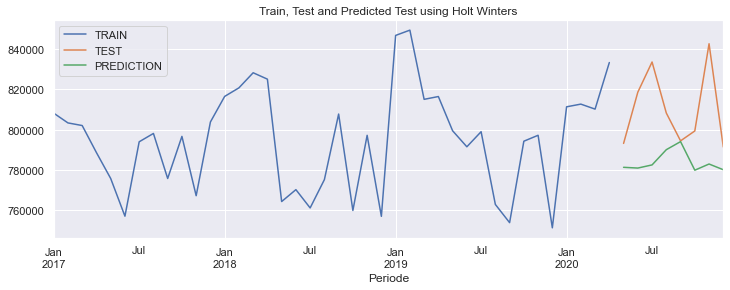

In [32]:
fitted_model = ExponentialSmoothing(train_prod['Produksi'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
test_predictions = fitted_model.forecast(len(test_prod))
train_prod['Produksi'].plot(legend=True,label='TRAIN')
test_prod['Produksi'].plot(legend=True,label='TEST',figsize=(12,4))
test_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted Test using Holt Winters')

# Visualisasi hasil prediksi

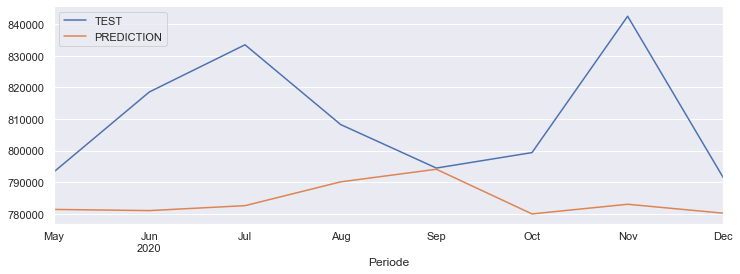

In [33]:
test_prod['Produksi'].plot(legend=True,label='TEST',figsize=(12,4))
test_predictions.plot(legend=True,label='PREDICTION');

In [34]:
print(f'Mean Absolute Error = {mean_absolute_error(test_prod,test_predictions)}')
print(f'Mean Squared Error = {mean_squared_error(test_prod,test_predictions)}')

Mean Absolute Error = 26147.065704926266
Mean Squared Error = 1066679543.5941939


In [35]:
f_prod.tail()

,Produksi
Periode,
2020-08-01,808237
2020-09-01,794454
2020-10-01,799353
2020-11-01,842555
2020-12-01,791401


# Prediksi dalam beberapa waktu ke depan

Kenapa dipilih mulai prediksi pada bulan Januari 2021? Karena data terakhir berada pada bulan Desember 2020

In [36]:
prediksi = fitted_model.predict(start=datetime(2021,1,1), end = datetime(2021,5,1))

# Mencetak hasil prediksi dan memvisualisasikan hasilnya

In [37]:
print(prediksi)

2021-01-01    830535.581375
2021-02-01    834765.899290
2021-03-01    822845.483969
2021-04-01    822641.304611
2021-05-01    783284.905871
Freq: MS, dtype: float64


Text(0.5, 1.0, 'Train, Test and Predicted Test using Holt Winters')

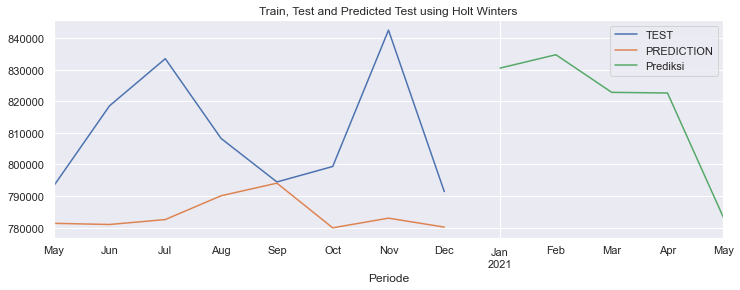

In [38]:
test_prod['Produksi'].plot(legend=True,label='TEST',figsize=(12,4))
test_predictions.plot(legend=True,label='PREDICTION');
prediksi.plot(legend=True, label='Prediksi')
plt.title('Train, Test and Predicted Test using Holt Winters')